# 단일 섹터 FA 스코어 백테스트

이 노트북은 `company_sector_rankings_2021_2025.csv`에 저장된 FA 스코어를 사용해서, 한 개 WICS 대분류 섹터 안에서 상위 종목을 고르고 다음 기간 수익률을 확인합니다.

핵심 질문은 다음과 같습니다.

- 같은 섹터 안에서 `overall_score`가 높은 기업을 고르면 이후 12개월 성과가 괜찮았는가?
- 섹터 전체 동일가중 포트폴리오와 비교했을 때 초과 성과가 있었는가?
- 어떤 연도에 잘 맞고, 어떤 연도에 잘 맞지 않았는가?

## 백테스트 기준

룩어헤드 바이어스를 줄이기 위해 아래처럼 시점을 잡습니다.

1. `score_year = Y`의 FA 스코어를 사용합니다.
2. 실제 매수는 `Y+1년 5월 초`에 한다고 가정합니다.
3. 보유기간은 기본 `12개월`입니다.
4. 섹터 내부에서 `overall_score` 상위 `TOP_N`개 종목을 동일가중으로 편입합니다.
5. 비교대상은 같은 섹터 전체 종목의 동일가중 수익률입니다.

왜 5월인가요? 국내 상장사의 전년도 사업보고서와 재무 데이터가 대체로 3월 말 이후 확인 가능하다고 보고, 실제 투자 가능 시점을 조금 늦춰 잡기 위해서입니다.

## 백테스트 로직 요약표

| 구분 | 기준 | 설명 |
|---|---|---|
| 투자 신호 | `overall_score` | 같은 회계연도·같은 WICS 대분류 안에서 계산된 FA 상대평가 점수 |
| 종목 선정 | `overall_score` 상위 `TOP_N` | 기본값은 IT 섹터 상위 10개 기업 |
| 매수 시점 | `score_year + 1`년 5월 2일 이후 첫 거래일 | 전년도 사업보고서와 재무 데이터가 확인된 뒤 투자한다고 가정 |
| 매도 시점 | 매수 기준일로부터 `HOLDING_DAYS`일 뒤 이전/당일 마지막 거래일 | 기본값은 약 12개월 보유 |
| 수익률 | `sell_close / buy_close - 1` | WICS 원천에서 역산한 `close_est` 기준 단순 보유수익률 |
| 전략 포트폴리오 | `score_top` | 스코어 상위 `TOP_N`개 동일가중 |
| 비교 포트폴리오 | `sector_equal` | 같은 섹터 전체 종목 동일가중 |
| 핵심 평가 | `excess_return` | `score_top` 수익률 - `sector_equal` 수익률 |

### 데이터 원천 요약

| 데이터 | 파일 | 백테스트에서의 역할 |
|---|---|---|
| FA 스코어 | `etl/wics_dart/output/company_sector_rankings_2021_2025.csv` | 섹터별 상위 종목 선정 신호 |
| 주식 가격 원천 | `etl/wics/data/csv/wics_company_2021~2025.zip` | 종목별 시가총액과 적용 주식 수로 추정 종가 계산 |
| 가격 계산 모듈 | `etl/wics_dart/core/wics_prices.py` | WICS zip 로드, `close_est` 계산, 보유수익률 계산 |

### 중요한 한계

| 한계 | 의미 |
|---|---|
| `close_est`는 추정 종가 | 실제 거래소 수정주가가 아니라 WICS 시가총액/적용주식수 기반 가격 |
| 배당 미반영 | 총수익률이 아니라 가격 수익률만 계산 |
| 거래비용·세금 미반영 | 실제 매매 성과보다 낙관적일 수 있음 |
| 2024년 점수 기본 제외 | 12개월 보유를 완성하려면 2026년 5월 가격이 필요하지만 현재 로컬 데이터는 2026년 3월까지만 있음 |


### 코드 설명: 기본 설정 셀

이 코드 셀은 필요한 라이브러리를 불러오고, 노트북이 어느 폴더에서 실행되더라도 프로젝트 루트를 찾도록 준비합니다. 또한 `core/wics_prices.py`를 import할 수 있게 `sys.path`를 설정합니다.


In [1]:
from __future__ import annotations

from datetime import datetime, timedelta
from pathlib import Path
import os
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 노트북 출력에서 pandas 경고가 너무 많이 보이지 않도록 숨깁니다.
warnings.filterwarnings("ignore")


def configure_korean_font() -> None:
    # Windows에서는 Malgun Gothic이 가장 안정적입니다.
    # 다른 환경에서 실행할 때를 대비해 자주 쓰는 한글 폰트를 순서대로 후보에 둡니다.
    font_candidates = [
        "Malgun Gothic",
        "AppleGothic",
        "NanumGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in font_candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False


configure_korean_font()

def find_project_root(start: Path) -> Path:
    # 노트북을 repo 루트에서 실행해도, notebooks 폴더에서 실행해도
    # `etl/wics_dart/output`을 기준으로 프로젝트 루트를 찾아냅니다.
    for candidate in [start, *start.parents]:
        if (candidate / "etl" / "wics_dart" / "output").exists():
            return candidate
    raise RuntimeError("프로젝트 루트를 찾지 못했습니다. 노트북을 repo 내부에서 실행해 주세요.")


# 이후 모든 파일 경로는 프로젝트 루트 기준으로 만듭니다.
ROOT = find_project_root(Path.cwd())

# core 모듈을 노트북에서 바로 import할 수 있도록 경로를 추가합니다.
WICS_DART_DIR = ROOT / "etl" / "wics_dart"
if str(WICS_DART_DIR) not in sys.path:
    sys.path.insert(0, str(WICS_DART_DIR))

from core.wics_prices import holding_returns_for_codes, load_wics_price_panel

# 스코어링 파이프라인이 만든 랭킹 CSV입니다.
RANKING_PATH = ROOT / "etl" / "wics_dart" / "output" / "company_sector_rankings_2021_2025.csv"

RANKING_PATH

WindowsPath('c:/dev/Project/Service_Stock_Analysis/etl/wics_dart/output/company_sector_rankings_2021_2025.csv')

## 파라미터

이 셀은 백테스트 조건을 한 곳에서 바꾸기 위한 설정 셀입니다. 아래 값만 바꾸면 같은 코드로 다른 섹터, 다른 편입 종목 수, 다른 보유기간을 테스트할 수 있습니다.

| 파라미터 | 의미 | 기본값 |
|---|---|---|
| `SECTOR_NAME` | 테스트할 WICS 대분류 | `IT` |
| `SCORE_YEARS` | 종목 선정에 사용할 회계연도 | `[2021, 2022, 2023]` |
| `TOP_N` | 매년 편입할 상위 종목 수 | `10` |
| `REBALANCE_MONTH`, `REBALANCE_DAY` | 매수 기준 월/일 | `5월 2일` |
| `HOLDING_DAYS` | 보유기간 | `365일` |

현재 로컬 가격 데이터는 2026년 3월까지만 있으므로, 12개월 보유를 완성하려면 기본값에서는 2024년과 2025년 점수를 제외합니다.

### 코드 설명: 파라미터 셀

여기서 백테스트 조건을 바꿉니다. 다른 섹터를 보고 싶으면 `SECTOR_NAME`, 편입 종목 수를 바꾸고 싶으면 `TOP_N`, 보유기간을 바꾸고 싶으면 `HOLDING_DAYS`를 수정하면 됩니다.


In [2]:
# 백테스트할 WICS 대분류입니다. 예: "IT", "산업재", "건강관리".
SECTOR_NAME = "IT"

# 사용할 회계연도입니다. 2024년은 2026년 5월 매도 가격이 필요해 기본 제외합니다.
SCORE_YEARS = [2021, 2022, 2023]

# 각 연도마다 overall_score 상위 몇 개 종목을 살지 정합니다.
TOP_N = 10

# 전년도 재무제표를 확인할 수 있다고 보는 매수 시점입니다.
REBALANCE_MONTH = 5
REBALANCE_DAY = 2

# 매수 후 며칠 동안 보유할지 정합니다. 365일은 약 12개월 보유입니다.
HOLDING_DAYS = 365

# 가격 데이터가 너무 많이 빠진 경우를 판별할 때 사용할 기준값입니다.
MIN_VALID_PRICE_RATIO = 0.7

# 현재 설정을 출력해서, 나중에 결과만 봐도 어떤 조건으로 돌렸는지 확인합니다.
print({
    "sector": SECTOR_NAME,
    "score_years": SCORE_YEARS,
    "top_n": TOP_N,
    "rebalance_month_day": f"{REBALANCE_MONTH:02d}-{REBALANCE_DAY:02d}",
    "holding_days": HOLDING_DAYS,
})

{'sector': 'IT', 'score_years': [2021, 2022, 2023], 'top_n': 10, 'rebalance_month_day': '05-02', 'holding_days': 365}


## 1. 스코어 데이터 로드

이 단계에서는 FA 스코어 결과 파일을 읽고, 백테스트에 필요한 타입을 정리합니다.

| 작업 | 이유 |
|---|---|
| `stock_code` 문자열 변환 | 종목코드 앞자리 0이 사라지는 문제 방지 |
| `fiscal_year` 숫자 변환 | 연도 필터링과 정렬을 안정적으로 수행 |
| `overall_score` 숫자 변환 | 점수 정렬과 상위 종목 선정을 위해 필요 |
| 섹터별 기업 수 확인 | 표본이 충분한 섹터인지 먼저 점검 |

백테스트의 신호는 `overall_score`입니다. 이 점수는 같은 연도, 같은 WICS 대분류 안에서 계산된 상대평가 점수입니다. 따라서 서로 다른 섹터를 섞어서 비교하지 않고, 하나의 섹터 안에서만 종목을 고릅니다.

### 코드 설명: 랭킹 데이터 로드 셀

`company_sector_rankings_2021_2025.csv`를 읽고 종목코드와 점수 타입을 정리합니다. 마지막의 `sector_counts.head(20)`은 어떤 섹터에 표본이 많은지 확인하는 진단용 출력입니다.


In [3]:
# 스코어링 파이프라인 결과를 읽습니다. stock_code는 앞자리 0이 중요하므로 문자열로 읽습니다.
rankings = pd.read_csv(RANKING_PATH, dtype={"stock_code": str})

# 종목코드, 회계연도, 점수 컬럼을 백테스트에 쓰기 좋은 타입으로 정리합니다.
rankings["stock_code"] = rankings["stock_code"].astype(str).str.split(".").str[0].str.zfill(6)
rankings["fiscal_year"] = pd.to_numeric(rankings["fiscal_year"], errors="coerce").astype("Int64")
rankings["overall_score"] = pd.to_numeric(rankings["overall_score"], errors="coerce")

# 연도별/섹터별 기업 수를 먼저 확인해, 테스트하기에 표본이 충분한 섹터를 고를 수 있게 합니다.
sector_counts = (
    rankings.groupby(["fiscal_year", "wics_large"])
    .size()
    .rename("company_count")
    .reset_index()
    .sort_values(["fiscal_year", "company_count"], ascending=[True, False])
)

sector_counts.head(20)

,fiscal_year,wics_large,company_count
0,2021,IT,709
4,2021,산업재,399
2,2021,경기관련소비재,392
1,2021,건강관리,357
5,2021,소재,240
3,2021,금융,190
8,2021,커뮤니케이션서비스,132
9,2021,필수소비재,102
6,2021,에너지,39
7,2021,유틸리티,18


### 코드 설명: 섹터 필터 셀

선택한 섹터와 연도만 남기고, `overall_score`가 없는 행은 제외합니다. 이 결과가 이후 모든 백테스트의 후보군이 됩니다.


In [4]:
# 선택한 섹터와 회계연도만 남깁니다.
# overall_score가 없는 기업은 포트폴리오 선정 신호가 없으므로 제외합니다.
sector_scores = rankings.loc[
    (rankings["wics_large"] == SECTOR_NAME)
    & rankings["fiscal_year"].isin(SCORE_YEARS)
    & rankings["overall_score"].notna()
].copy()

# 섹터명을 잘못 입력했거나 해당 기간 데이터가 없으면 바로 알려줍니다.
if sector_scores.empty:
    raise ValueError(f"선택한 섹터에 백테스트 가능한 점수 데이터가 없습니다: {SECTOR_NAME}")

sector_scores[["fiscal_year", "company_name", "stock_code", "overall_score", "overall_bucket", "score_model"]].head(10)

,fiscal_year,company_name,stock_code,overall_score,overall_bucket,score_model
0,2021,노바텍,285490,0.968396,top_20%,fallback
1,2021,넥스틴,348210,0.948661,top_20%,fallback
2,2021,알서포트,131370,0.946031,top_20%,fallback
3,2021,시큐브,131090,0.920537,top_20%,fallback
4,2021,프로텍,053610,0.920191,top_20%,fallback
5,2021,슈프리마,236200,0.913935,top_20%,fallback
6,2021,덕산네오룩스,213420,0.910421,top_20%,fallback
7,2021,브이엠,089970,0.908655,top_20%,fallback
8,2021,테스,095610,0.901060,top_20%,fallback
9,2021,피에스케이홀딩스,031980,0.898251,top_20%,fallback


## 2. 연도별 편입 종목 선정

이 단계는 실제 전략 포트폴리오인 `score_top`을 만드는 과정입니다.

| 입력 | 처리 | 출력 |
|---|---|---|
| 선택 섹터의 기업-연도별 스코어 | 연도별로 `overall_score` 내림차순 정렬 | 매년 상위 `TOP_N` 종목 |
| 동점 종목 | `company_name` 기준 추가 정렬 | 실행할 때마다 동일한 결과 유지 |

중요한 점은 연도별로 따로 뽑는다는 것입니다. 2021년 점수와 2023년 점수를 섞어 정렬하면 시점이 섞이므로 백테스트가 왜곡됩니다.

### 코드 설명: 포트폴리오 선정 셀

`select_top_portfolios` 함수는 연도별로 점수 상위 종목을 고릅니다. 출력 표는 실제로 어떤 기업이 전략 포트폴리오에 들어가는지 확인하는 용도입니다.


In [5]:
def select_top_portfolios(scores: pd.DataFrame, top_n: int) -> pd.DataFrame:
    # 회계연도별로 따로 상위 종목을 고릅니다.
    # 이렇게 해야 2021년 점수와 2024년 점수가 서로 섞이지 않습니다.
    frames = []
    for year, group in scores.groupby("fiscal_year"):
        # 점수가 높은 종목부터 고르고, 동점이면 회사명 순서로 고정합니다.
        selected = (
            group.sort_values(["overall_score", "company_name"], ascending=[False, True])
            .head(top_n)
            .copy()
        )
        # 사람이 보기 쉽도록 포트폴리오 내부 순번을 붙입니다.
        selected["portfolio_rank"] = range(1, len(selected) + 1)
        frames.append(selected)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


# 실제 백테스트에서 사용할 score_top 포트폴리오 구성표입니다.
top_portfolios = select_top_portfolios(sector_scores, TOP_N)
top_portfolios[["fiscal_year", "portfolio_rank", "company_name", "stock_code", "overall_score", "overall_bucket"]]

,fiscal_year,portfolio_rank,company_name,stock_code,overall_score,overall_bucket
0,2021,1,노바텍,285490,0.968396,top_20%
1,2021,2,넥스틴,348210,0.948661,top_20%
2,2021,3,알서포트,131370,0.946031,top_20%
3,2021,4,시큐브,131090,0.920537,top_20%
4,2021,5,프로텍,053610,0.920191,top_20%
5,2021,6,슈프리마,236200,0.913935,top_20%
6,2021,7,덕산네오룩스,213420,0.910421,top_20%
7,2021,8,브이엠,089970,0.908655,top_20%
8,2021,9,테스,095610,0.901060,top_20%
9,2021,10,피에스케이홀딩스,031980,0.898251,top_20%


## 3. 로컬 WICS 가격 데이터 준비

가격 데이터는 `etl/wics/data/csv/wics_company_2021~2025.zip`을 사용합니다. 이 파일에는 직접 종가 컬럼은 없지만, 종목별 시가총액과 적용 주식 수가 있으므로 아래 방식으로 종가를 역산합니다.

```text
close_est = MKT_VAL * 1,000,000 / APT_SHR_CNT
```

이 방식은 외부 네트워크나 `pykrx` 없이 로컬 데이터만으로 재현 가능한 장점이 있습니다. 단, `close_est`는 WICS 지수 산출용 적용 주식 수 기반 추정 종가이므로 수정주가, 배당, 거래비용은 반영하지 않습니다.


### 코드 설명: 가격 패널 준비 셀

`load_wics_price_panel`은 WICS zip 파일을 읽고 `close_est`를 계산합니다. 여기서는 선택 섹터 가격만 읽기 때문에 전체 시장을 읽는 것보다 빠릅니다.


In [6]:
# 백테스트 기간에는 score_year 다음 해부터 그 다음 해까지 가격이 필요합니다.
# 예: 2021 score -> 2022년 매수, 2023년 매도.
PRICE_YEARS = sorted({year + 1 for year in SCORE_YEARS} | {year + 2 for year in SCORE_YEARS})

# 선택한 섹터의 종목만 읽어 메모리 사용량을 줄입니다.
# WICS zip 원천에서 close_est를 계산하고 date-stock 기준 중복을 제거합니다.
price_panel = load_wics_price_panel(
    PRICE_YEARS,
    root=ROOT,
    wics_large=SECTOR_NAME,
)

if price_panel.empty:
    raise ValueError(f"선택한 섹터의 가격 데이터가 없습니다: {SECTOR_NAME}")

print({
    "price_years": PRICE_YEARS,
    "rows": len(price_panel),
    "stocks": price_panel["stock_code"].nunique(),
    "start_date": price_panel["date"].min().date(),
    "end_date": price_panel["date"].max().date(),
})

price_panel.head()


{'price_years': [2022, 2023, 2024, 2025], 'rows': 639959, 'stocks': 788, 'start_date': datetime.date(2022, 1, 3), 'end_date': datetime.date(2025, 12, 30)}


,stock_code,company_name,market_cap_wics_raw,wics_large_code,wics_large,shares_applied,date,trading_value_wics_raw,close_est
0,000660,SK하이닉스,69225745,G45,IT,538721750,2022-01-03,3176592,128500.000232
1,000670,영풍,180428,G45,IT,276306,2022-01-03,1296671,653000.658690
2,000990,DB하이텍,2663116,G45,IT,34630899,2022-01-03,3176592,76899.996157
3,001210,금호전기,48686,G45,IT,13158303,2022-01-03,551888,3700.021196
4,001820,삼화콘덴서,446517,G45,IT,7380450,2022-01-03,832645,60499.969514


## 4. 백테스트 실행

연도별로 두 개 포트폴리오를 계산합니다.

| 포트폴리오 | 구성 | 목적 |
|---|---|---|
| `score_top` | FA 스코어 상위 `TOP_N` 동일가중 | 스코어 기반 전략 성과 확인 |
| `sector_equal` | 같은 섹터 전체 동일가중 | 섹터 평균 대비 초과성과 확인 |

계산 순서는 다음과 같습니다.

1. `score_year`별 매수/매도 기준일을 만든다.
2. 기준일이 휴장일이면 실제 가격 데이터에서 가장 가까운 거래일을 사용한다.
3. 종목별 보유수익률을 계산한다.
4. 가격이 있는 종목만 동일가중 평균한다.
5. 연도별 요약표와 종목별 상세표를 따로 저장한다.

### 코드 설명: 백테스트 실행 셀

`rebalance_window`는 회계연도별 매수/매도 기준일을 만들고, `backtest_group`은 각 포트폴리오의 종목별 수익률과 동일가중 평균 수익률을 계산합니다.


In [7]:
def ymd(date: datetime) -> str:
    # WICS 날짜 비교와 출력에 쓰기 쉬운 YYYYMMDD 문자열로 바꿉니다.
    return date.strftime("%Y%m%d")


def rebalance_window(score_year: int) -> tuple[str, str]:
    # score_year의 재무 점수는 다음 해 5월 초부터 투자 가능하다고 가정합니다.
    start = datetime(score_year + 1, REBALANCE_MONTH, REBALANCE_DAY)
    end = start + timedelta(days=HOLDING_DAYS)
    return ymd(start), ymd(end)


def backtest_group(group: pd.DataFrame, portfolio_name: str, start_date: str, end_date: str) -> tuple[dict, pd.DataFrame]:
    # 하나의 포트폴리오(score_top 또는 sector_equal)에 대해 종목별 수익률을 계산합니다.
    # 종목을 하나씩 필터링하면 느리므로, holding_returns_for_codes에서 한 번에 계산합니다.
    lookup = group.drop_duplicates("stock_code").set_index("stock_code")
    detail = holding_returns_for_codes(
        price_panel,
        lookup.index.tolist(),
        pd.to_datetime(start_date),
        pd.to_datetime(end_date),
    )
    detail["return"] = detail["holding_return"]

    # 나중에 결과표에서 바로 해석할 수 있도록 회사명과 점수를 함께 붙입니다.
    detail["company_name"] = detail["stock_code"].map(lookup["company_name"])
    detail["overall_score"] = detail["stock_code"].map(lookup["overall_score"])

    # detail은 종목별 결과, summary는 포트폴리오 단위 요약입니다.
    detail["portfolio"] = portfolio_name
    detail["requested_start_date"] = start_date
    detail["requested_end_date"] = end_date
    # 가격이 정상적으로 있는 종목만 동일가중 평균에 사용합니다.
    valid = detail.dropna(subset=["return"])
    summary = {
        "portfolio": portfolio_name,
        "requested_start_date": start_date,
        "requested_end_date": end_date,
        "candidate_count": len(detail),
        "valid_count": len(valid),
        "valid_ratio": len(valid) / len(detail) if len(detail) else 0,
        # 현재 버전은 모든 유효 종목을 같은 비중으로 보유한다고 가정합니다.
        "equal_weight_return": valid["return"].mean() if not valid.empty else pd.NA,
        "best_stock": valid.sort_values("return", ascending=False).iloc[0]["company_name"] if not valid.empty else pd.NA,
        "worst_stock": valid.sort_values("return", ascending=True).iloc[0]["company_name"] if not valid.empty else pd.NA,
    }
    return summary, detail


# 전체 연도/포트폴리오 반복 결과를 담을 리스트입니다.
summary_rows = []
detail_rows = []

for score_year in SCORE_YEARS:
    # 회계연도별로 투자 시작/종료일을 계산합니다.
    start_date, end_date = rebalance_window(score_year)

    # 비교군 1: 섹터 전체, 비교군 2: 스코어 상위 종목군입니다.
    year_sector = sector_scores.loc[sector_scores["fiscal_year"] == score_year].copy()
    year_top = top_portfolios.loc[top_portfolios["fiscal_year"] == score_year].copy()

    for portfolio_name, group in [("score_top", year_top), ("sector_equal", year_sector)]:
        summary, detail = backtest_group(group, portfolio_name, start_date, end_date)
        # 회계연도를 붙여두면 여러 해 결과를 합친 뒤에도 출처가 사라지지 않습니다.
        summary["score_year"] = score_year
        detail["score_year"] = score_year
        summary_rows.append(summary)
        detail_rows.append(detail)

backtest_summary = pd.DataFrame(summary_rows)
backtest_detail = pd.concat(detail_rows, ignore_index=True) if detail_rows else pd.DataFrame()

backtest_summary

,portfolio,requested_start_date,requested_end_date,candidate_count,valid_count,valid_ratio,equal_weight_return,best_stock,worst_stock,score_year
0,score_top,20220502,20230502,10,10,1.000000,-0.193334,덕산네오룩스,브이엠,2021
1,sector_equal,20220502,20230502,471,455,0.966030,-0.086344,케이이엠텍,MDS테크,2021
2,score_top,20230502,20240501,10,10,1.000000,-0.100280,케이아이엔엑스,포시에스,2022
3,sector_equal,20230502,20240501,511,498,0.974560,0.077638,한미반도체,엑스페릭스,2022
4,score_top,20240502,20250502,10,10,1.000000,-0.120610,비츠로셀,이닉스,2023
5,sector_equal,20240502,20250502,539,532,0.987013,-0.147357,디모아,영풍,2023


## 5. 결과 비교

`excess_return`은 스코어 상위 포트폴리오 수익률에서 섹터 전체 동일가중 수익률을 뺀 값입니다. 이 값이 양수면 해당 연도에는 FA 스코어 상위 종목군이 섹터 평균보다 좋았다는 뜻입니다.

### 코드 설명: 결과 비교 셀

연도별 `score_top` 수익률과 `sector_equal` 수익률을 한 표로 합치고, 두 값의 차이인 `excess_return`을 계산합니다.


In [8]:
# 포트폴리오별 요약 결과를 연도 1행 형태로 바꿉니다.
# 이렇게 해야 score_top과 sector_equal을 바로 뺄 수 있습니다.
comparison = (
    backtest_summary.pivot(index="score_year", columns="portfolio", values="equal_weight_return")
    .reset_index()
)
# 초과수익률 = 스코어 상위 포트폴리오 - 섹터 전체 동일가중 포트폴리오.
comparison["excess_return"] = comparison["score_top"] - comparison["sector_equal"]

# 해당 연도에 스코어 상위 전략이 섹터 평균을 이겼는지 True/False로 표시합니다.
comparison["score_top_win"] = comparison["excess_return"] > 0

# 핵심 컬럼만 보기 좋게 백분율 형식으로 출력합니다.
display_cols = ["score_year", "score_top", "sector_equal", "excess_return", "score_top_win"]
formatted_comparison = comparison[display_cols].copy()
for column in ["score_top", "sector_equal", "excess_return"]:
    formatted_comparison[column] = formatted_comparison[column].map(lambda value: f"{value:.2%}" if pd.notna(value) else "-")

formatted_comparison = formatted_comparison.rename(
    columns={
        "score_year": "점수연도",
        "score_top": "스코어 상위 수익률",
        "sector_equal": "섹터 평균 수익률",
        "excess_return": "초과수익률",
        "score_top_win": "섹터 평균 대비 승리",
    }
)
formatted_comparison

portfolio,점수연도,스코어 상위 수익률,섹터 평균 수익률,초과수익률,섹터 평균 대비 승리
0,2021,-19.33%,-8.63%,-10.70%,False
1,2022,-10.03%,7.76%,-17.79%,False
2,2023,-12.06%,-14.74%,2.67%,True


### 코드 설명: 전체 요약 셀

여러 연도 결과를 평균 수익률, 평균 초과수익률, 승률로 압축합니다. 전략이 한 해만 우연히 좋았는지, 여러 해에 걸쳐 일관성이 있었는지 보는 데 사용합니다.


In [9]:
# 여러 연도 결과를 하나로 요약합니다.
# 평균 수익률뿐 아니라 승률도 같이 봐야 특정 한 해에만 의존했는지 판단할 수 있습니다.
overall_result = {
    "sector": SECTOR_NAME,
    "test_count": len(comparison),
    "win_rate": comparison["score_top_win"].mean(),
    "avg_score_top_return": comparison["score_top"].mean(),
    "avg_sector_equal_return": comparison["sector_equal"].mean(),
    "avg_excess_return": comparison["excess_return"].mean(),
}

# Series로 출력하면 노트북에서 간단한 요약표처럼 확인할 수 있습니다.
overall_result_kr = pd.Series(
    {
        "섹터": overall_result["sector"],
        "테스트 연도 수": overall_result["test_count"],
        "승률": overall_result["win_rate"],
        "스코어 상위 평균 수익률": overall_result["avg_score_top_return"],
        "섹터 평균 수익률": overall_result["avg_sector_equal_return"],
        "평균 초과수익률": overall_result["avg_excess_return"],
    }
)
overall_result_kr

섹터                     IT
테스트 연도 수                3
승률               0.333333
스코어 상위 평균 수익률   -0.138075
섹터 평균 수익률       -0.052021
평균 초과수익률        -0.086054
dtype: object

## 6. 그래프로 결과 비교

표는 정확한 수치를 확인하기 좋지만, 전략이 어느 해에 섹터 평균을 이겼는지와 누적 성과가 어떻게 벌어지는지는 그래프로 보는 편이 더 직관적입니다.

이 섹션에서는 네 가지를 봅니다. 그래프 제목, 범례, 축 라벨은 한글로 표시되도록 설정했습니다.

| 그래프 | 확인할 내용 |
|---|---|
| 연도별 수익률 막대그래프 | `score_top`과 `sector_equal`의 연도별 성과 차이 |
| 초과수익률 막대그래프 | 전략이 섹터 평균을 이긴 해와 진 해 |
| 누적 성과 라인그래프 | 여러 해를 연속 투자했다고 가정했을 때 성과 흐름 |
| 편입 종목 수익률 분포 | 특정 종목 몇 개가 성과를 좌우했는지 여부 |


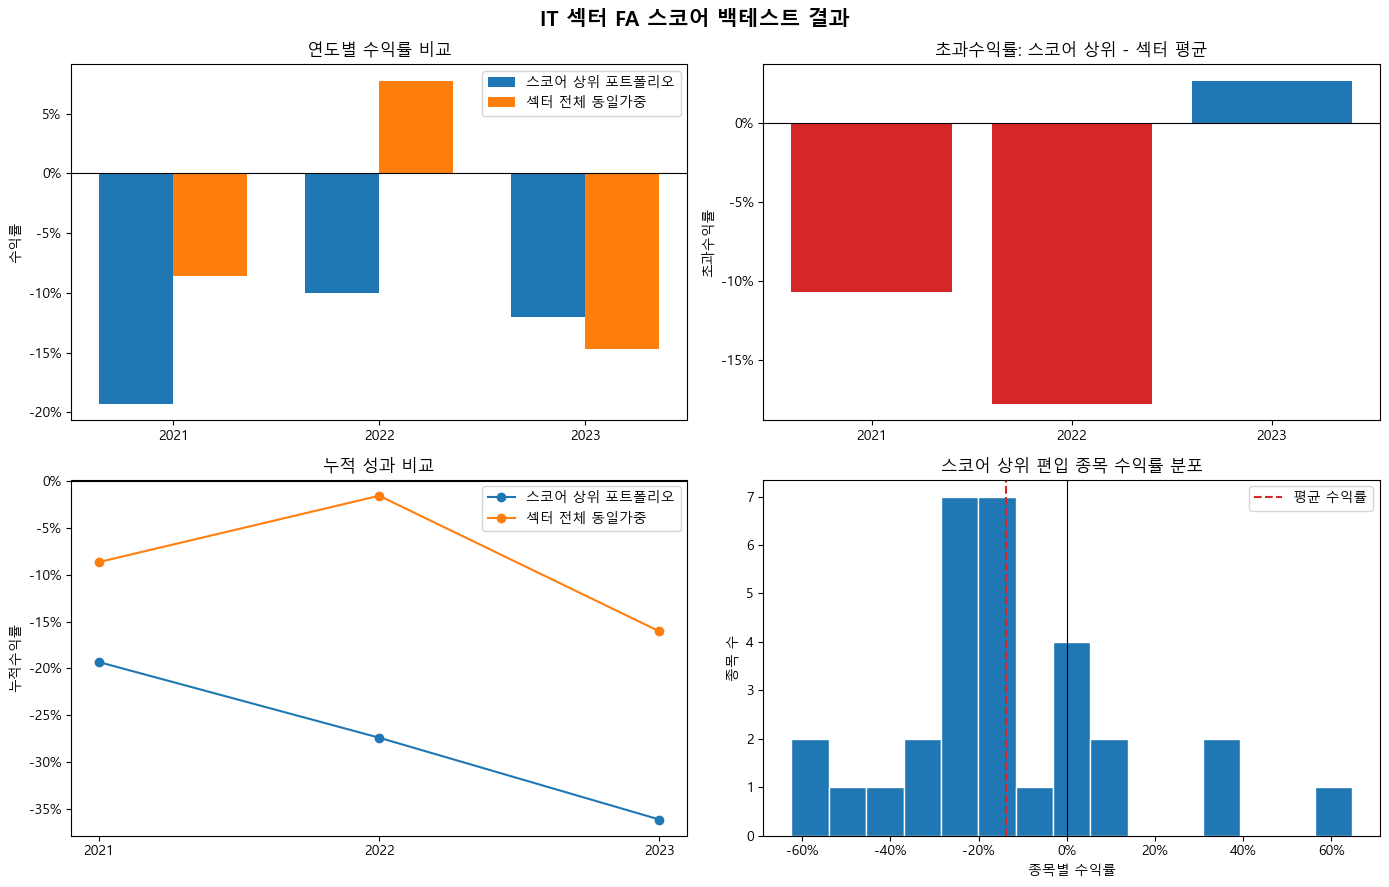

In [10]:
# 그래프에 사용할 데이터를 숫자형으로 정리합니다.
plot_data = comparison.copy()
plot_data = plot_data.sort_values("score_year")
plot_data["score_year_label"] = plot_data["score_year"].astype(str)

# 누적 성과는 각 연도 수익률을 순차적으로 재투자한다고 가정해 계산합니다.
plot_data["score_top_cumulative"] = (1 + plot_data["score_top"]).cumprod() - 1
plot_data["sector_equal_cumulative"] = (1 + plot_data["sector_equal"]).cumprod() - 1

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"{SECTOR_NAME} 섹터 FA 스코어 백테스트 결과", fontsize=15, fontweight="bold")

# 1. 연도별 전략 수익률 비교
x = range(len(plot_data))
bar_width = 0.36
axes[0, 0].bar([i - bar_width / 2 for i in x], plot_data["score_top"], width=bar_width, label="스코어 상위 포트폴리오")
axes[0, 0].bar([i + bar_width / 2 for i in x], plot_data["sector_equal"], width=bar_width, label="섹터 전체 동일가중")
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("연도별 수익률 비교")
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(plot_data["score_year_label"])
axes[0, 0].set_ylabel("수익률")
axes[0, 0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[0, 0].legend()

# 2. 초과수익률 확인
colors = ["tab:blue" if value >= 0 else "tab:red" for value in plot_data["excess_return"]]
axes[0, 1].bar(plot_data["score_year_label"], plot_data["excess_return"], color=colors)
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("초과수익률: 스코어 상위 - 섹터 평균")
axes[0, 1].set_ylabel("초과수익률")
axes[0, 1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

# 3. 누적 성과 비교
axes[1, 0].plot(plot_data["score_year_label"], plot_data["score_top_cumulative"], marker="o", label="스코어 상위 포트폴리오")
axes[1, 0].plot(plot_data["score_year_label"], plot_data["sector_equal_cumulative"], marker="o", label="섹터 전체 동일가중")
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_title("누적 성과 비교")
axes[1, 0].set_ylabel("누적수익률")
axes[1, 0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1, 0].legend()

# 4. score_top 편입 종목의 개별 수익률 분포
score_top_returns = backtest_detail.loc[backtest_detail["portfolio"] == "score_top", "return"].dropna()
axes[1, 1].hist(score_top_returns, bins=15, edgecolor="white")
axes[1, 1].axvline(score_top_returns.mean(), color="tab:red", linestyle="--", label="평균 수익률")
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("스코어 상위 편입 종목 수익률 분포")
axes[1, 1].set_xlabel("종목별 수익률")
axes[1, 1].set_ylabel("종목 수")
axes[1, 1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 7. 자동 해석 리포트

이 섹션은 앞에서 계산한 백테스트 결과를 문장으로 풀어줍니다. 표와 그래프를 볼 때 놓치기 쉬운 부분을 아래 관점으로 정리합니다.

| 해석 항목 | 보는 이유 |
|---|---|
| 평균 초과수익률 | 스코어 상위 전략이 섹터 평균보다 구조적으로 나았는지 확인 |
| 승률 | 특정 한 해에만 성과가 몰렸는지 확인 |
| 최고/최저 연도 | 어떤 시장 국면에서 전략이 잘 맞았는지 확인 |
| 편입 종목 분포 | 소수 종목이 전체 성과를 좌우했는지 확인 |
| 가격 데이터 유효성 | 누락 데이터 때문에 결과가 왜곡됐는지 확인 |


In [11]:
def format_pct(value: float | None) -> str:
    # 해석 문장에서 수익률을 보기 좋게 표시합니다.
    if pd.isna(value):
        return "-"
    return f"{value:.2%}"


# 연도별 성과를 기준으로 전략의 강점/약점을 요약합니다.
valid_comparison = comparison.dropna(subset=["score_top", "sector_equal", "excess_return"]).copy()

if valid_comparison.empty:
    print("해석 가능한 백테스트 결과가 없습니다. 가격 데이터와 SCORE_YEARS 설정을 확인하세요.")
else:
    best_year_row = valid_comparison.sort_values("excess_return", ascending=False).iloc[0]
    worst_year_row = valid_comparison.sort_values("excess_return", ascending=True).iloc[0]
    avg_excess = valid_comparison["excess_return"].mean()
    win_rate = valid_comparison["score_top_win"].mean()
    avg_score_return = valid_comparison["score_top"].mean()
    avg_sector_return = valid_comparison["sector_equal"].mean()

    score_top_detail = backtest_detail.loc[backtest_detail["portfolio"] == "score_top"].dropna(subset=["return"]).copy()
    positive_ratio = (score_top_detail["return"] > 0).mean() if not score_top_detail.empty else pd.NA
    best_stock = score_top_detail.sort_values("return", ascending=False).iloc[0] if not score_top_detail.empty else None
    worst_stock = score_top_detail.sort_values("return", ascending=True).iloc[0] if not score_top_detail.empty else None

    print("[전략 요약]")
    print(f"- 테스트 섹터: {SECTOR_NAME}")
    print(f"- 테스트 연도: {', '.join(map(str, SCORE_YEARS))}")
    print(f"- 매년 편입 종목 수: 상위 {TOP_N}개")
    print(f"- 스코어 상위 평균 수익률: {format_pct(avg_score_return)}")
    print(f"- 섹터 전체 동일가중 평균 수익률: {format_pct(avg_sector_return)}")
    print(f"- 평균 초과수익률: {format_pct(avg_excess)}")
    print(f"- 섹터 평균 대비 승률: {format_pct(win_rate)}")

    print()
    print("[연도별 해석]")
    print(
        f"- 가장 좋았던 해: {int(best_year_row['score_year'])}년 "
        f"({format_pct(best_year_row['excess_return'])} 초과수익)"
    )
    print(
        f"- 가장 부진했던 해: {int(worst_year_row['score_year'])}년 "
        f"({format_pct(worst_year_row['excess_return'])} 초과수익)"
    )

    print()
    print("[종목 분포 해석]")
    if not score_top_detail.empty:
        print(f"- 편입 종목 중 플러스 수익률 비중: {format_pct(positive_ratio)}")
        print(
            f"- 최고 기여 종목: {best_stock['company_name']} "
            f"({best_stock['stock_code']}, {format_pct(best_stock['return'])})"
        )
        print(
            f"- 최저 기여 종목: {worst_stock['company_name']} "
            f"({worst_stock['stock_code']}, {format_pct(worst_stock['return'])})"
        )
    else:
        print("- 종목별 수익률 데이터가 부족합니다.")

    print()
    print("[판단 가이드]")
    if avg_excess > 0 and win_rate >= 0.5:
        print("- 현재 설정에서는 스코어 상위 전략이 섹터 평균보다 유리한 신호를 보였습니다.")
        print("- 다음 단계에서는 다른 TOP_N, 보유기간, 다른 섹터에서도 같은 현상이 반복되는지 확인하는 것이 좋습니다.")
    elif avg_excess > 0 and win_rate < 0.5:
        print("- 평균 초과수익은 양수지만 승률은 낮습니다. 일부 연도나 일부 종목에 성과가 집중됐을 가능성이 있습니다.")
        print("- 종목별 상세표와 수익률 분포 그래프를 함께 확인해야 합니다.")
    elif avg_excess <= 0 and win_rate >= 0.5:
        print("- 이긴 해는 비교적 있지만 평균 초과수익은 낮습니다. 손실이 난 해의 하락 폭이 컸을 수 있습니다.")
        print("- 리스크 관리나 하위 점수 종목 제외 기준을 추가로 검토할 필요가 있습니다.")
    else:
        print("- 현재 설정에서는 스코어 상위 전략이 섹터 평균을 뚜렷하게 이기지 못했습니다.")
        print("- 스코어링 기준, TOP_N, 매수 시점, 보유기간을 바꿔 민감도 분석을 해보는 것이 좋습니다.")


[전략 요약]
- 테스트 섹터: IT
- 테스트 연도: 2021, 2022, 2023
- 매년 편입 종목 수: 상위 10개
- 스코어 상위 평균 수익률: -13.81%
- 섹터 전체 동일가중 평균 수익률: -5.20%
- 평균 초과수익률: -8.61%
- 섹터 평균 대비 승률: 33.33%

[연도별 해석]
- 가장 좋았던 해: 2023년 (2.67% 초과수익)
- 가장 부진했던 해: 2022년 (-17.79% 초과수익)

[종목 분포 해석]
- 편입 종목 중 플러스 수익률 비중: 20.00%
- 최고 기여 종목: 케이아이엔엑스 (093320, 64.65%)
- 최저 기여 종목: 포시에스 (189690, -62.45%)

[판단 가이드]
- 현재 설정에서는 스코어 상위 전략이 섹터 평균을 뚜렷하게 이기지 못했습니다.
- 스코어링 기준, TOP_N, 매수 시점, 보유기간을 바꿔 민감도 분석을 해보는 것이 좋습니다.


### 해석 체크리스트

아래 체크리스트를 따라가면 결과를 더 안정적으로 읽을 수 있습니다.

| 질문 | 좋게 볼 수 있는 신호 | 주의할 신호 |
|---|---|---|
| 평균 초과수익률이 양수인가? | `score_top`이 섹터 평균보다 높음 | 평균이 음수면 현재 점수 기준이 수익률로 연결되지 않았을 수 있음 |
| 승률이 충분한가? | 여러 해에 걸쳐 섹터 평균을 이김 | 한 해만 크게 좋아 평균을 끌어올렸을 수 있음 |
| 누적 성과가 우상향인가? | 전략이 시간이 갈수록 섹터 평균과 벌어짐 | 특정 연도 손실로 누적 성과가 무너짐 |
| 종목별 분포가 고른가? | 다수 종목이 비슷하게 기여 | 한두 종목이 전체 성과를 좌우 |
| 가격 데이터가 충분한가? | `valid_ratio`가 높음 | 가격 누락 종목이 많으면 평균 수익률 왜곡 가능 |

### 이 결과로 바로 결론 내리면 안 되는 이유

| 한계 | 보완 방법 |
|---|---|
| 한 섹터만 테스트 | 다른 섹터에서도 반복 실행 |
| 기본 `TOP_N=10`만 확인 | `TOP_N=5`, `20`, `30` 등 민감도 분석 |
| 보유기간 365일 고정 | 3개월, 6개월, 18개월 등 비교 |
| 거래비용·세금 미반영 | 실전 가정에 맞는 비용 차감 로직 추가 |
| 추정 종가 사용 | 필요 시 거래소 수정주가 또는 pykrx 가격과 교차검증 |

### 다음 분석 아이디어

1. `SECTOR_NAME`을 바꿔 섹터별 결과 비교
2. `TOP_N`을 바꿔 집중투자와 분산투자 차이 확인
3. `HOLDING_DAYS`를 바꿔 보유기간 민감도 확인
4. `overall_score` 대신 `growth_score`, `profitability_score` 등 단일 점수 전략 비교
5. 결과가 좋은 섹터에 한해 머신러닝 라벨 데이터셋 생성


## 8. 편입 종목별 수익률 확인

아래 표는 스코어 상위 포트폴리오에 실제 편입된 종목만 보여줍니다. 점수는 좋았지만 이후 수익률이 나빴던 종목, 또는 점수와 수익률이 같이 좋았던 종목을 확인할 수 있습니다.

### 코드 설명: 종목별 상세 셀

`score_top`에 편입된 종목만 따로 뽑아 실제 매수일, 매도일, 매수가, 매도가, 수익률을 확인합니다. 어떤 종목이 전략 성과를 만들었는지 보는 셀입니다.


In [12]:
# 상세 분석은 실제 전략 포트폴리오인 score_top 종목만 따로 봅니다.
top_detail = backtest_detail.loc[backtest_detail["portfolio"] == "score_top"].copy()

# 연도별로 묶고, 같은 연도 안에서는 수익률이 높은 순서로 정렬합니다.
top_detail = top_detail.sort_values(["score_year", "return"], ascending=[True, False])

# 점수, 실제 사용된 거래일, 시작/종료 가격, 수익률을 함께 확인합니다.
top_detail_display = top_detail[[
    "score_year",
    "company_name",
    "stock_code",
    "overall_score",
    "buy_date_actual",
    "sell_date_actual",
    "buy_close",
    "sell_close",
    "return",
]].copy()

# 숫자는 사람이 읽기 편한 형식으로 표시합니다.
top_detail_display["overall_score"] = top_detail_display["overall_score"].map(lambda value: f"{value:.3f}" if pd.notna(value) else "-")
top_detail_display["buy_close"] = top_detail_display["buy_close"].map(lambda value: f"{value:,.0f}" if pd.notna(value) else "-")
top_detail_display["sell_close"] = top_detail_display["sell_close"].map(lambda value: f"{value:,.0f}" if pd.notna(value) else "-")
top_detail_display["return"] = top_detail_display["return"].map(lambda value: f"{value:.2%}" if pd.notna(value) else "-")

top_detail_display = top_detail_display.rename(
    columns={
        "score_year": "점수연도",
        "company_name": "기업명",
        "stock_code": "종목코드",
        "overall_score": "FA 점수",
        "buy_date_actual": "실제 매수일",
        "sell_date_actual": "실제 매도일",
        "buy_close": "매수가",
        "sell_close": "매도가",
        "return": "수익률",
    }
)
top_detail_display

,점수연도,기업명,종목코드,FA 점수,실제 매수일,실제 매도일,매수가,매도가,수익률
6,2021,덕산네오룩스,213420,0.910,2022-05-02,2023-05-02,"41,800","43,600",4.31%
1,2021,넥스틴,348210,0.949,2022-05-02,2023-05-02,"69,500","66,600",-4.17%
5,2021,슈프리마,236200,0.914,2022-05-02,2023-05-02,"24,800","21,600",-12.90%
0,2021,노바텍,285490,0.968,2022-05-02,2023-05-02,"38,000","32,200",-15.26%
4,2021,프로텍,053610,0.920,2022-05-02,2023-05-02,"29,300","24,600",-16.04%
8,2021,테스,095610,0.901,2022-05-02,2023-05-02,"27,400","21,450",-21.72%
3,2021,시큐브,131090,0.921,2022-05-02,2023-05-02,"1,400","1,075",-23.21%
2,2021,알서포트,131370,0.946,2022-05-02,2023-05-02,"5,340","3,920",-26.59%
9,2021,피에스케이홀딩스,031980,0.898,2022-05-02,2023-05-02,"13,500","9,090",-32.67%
7,2021,브이엠,089970,0.909,2022-05-02,2023-05-02,"20,700","11,370",-45.07%


## 9. 해석 가이드

결과를 볼 때는 다음 순서로 판단합니다.

1. `valid_ratio`가 충분히 높은지 확인합니다. 가격 데이터가 너무 많이 빠지면 결과 신뢰도가 낮습니다.
2. `score_top`이 `sector_equal`보다 꾸준히 높은지 봅니다. 한 해만 좋은 것보다 여러 해에 걸친 일관성이 중요합니다.
3. `excess_return` 평균과 승률을 함께 봅니다. 평균은 높지만 승률이 낮다면 일부 대박 종목에 의존했을 수 있습니다.
4. 편입 종목별 수익률을 확인합니다. 스코어가 높은데 반복적으로 부진한 유형이 있으면 스코어링 기준을 조정할 후보입니다.

이 백테스트는 단순 검증용입니다. 더 엄밀하게 만들려면 거래비용, 상장폐지/거래정지, 수정주가, 시가 매수 여부, 리밸런싱 날짜, 재무제표 실제 공시일을 추가로 반영해야 합니다.